📁 Trovati 2 file CSV

   ✓ ES pattern 5.csv........................ -> ES...... (346 righe)
   ✓ nq pattern 5.csv........................ -> NQ...... (136 righe)

📊 Dataset totale: 482 righe
🎯 Ticker: ['ES', 'NQ']

🔍 Pulizia dati...

📋 Sample 'Profit' PRIMA pulizia:
['$169.24', '($205.76)', '$294.24', '$1344.24', '$356.74', '($5.76)', '($93.26)', '$244.24', '$594.24', '($968.26)']

🧹 Sample 'Net profit' DOPO pulizia:
[169.24, -205.76, 294.24, 1344.24, 356.74, -5.76, -93.26, 244.24, 594.24, -968.26]

✅ Date parsate correttamente

🧹 Righe valide: 482 (rimosse 0)

📊 Statistiche base NET PROFIT:
   Min:   €-10,655.68
   Max:   €25,556.74
   Mean:  €255.32
   Total: €123,064.56

🎯 STATISTICHE PER TICKER

ES:
  Trade totali:  346
  Total Profit:  €70,507.04
  Avg Trade:     €203.78
  Win Rate:      53.2%
  Best Trade:    €25556.74
  Worst Trade:   €-5868.26

NQ:
  Trade totali:  136
  Total Profit:  €52,557.52
  Avg Trade:     €386.45
  Win Rate:      50.7%
  Best Trade:    €10789.32
  Worst

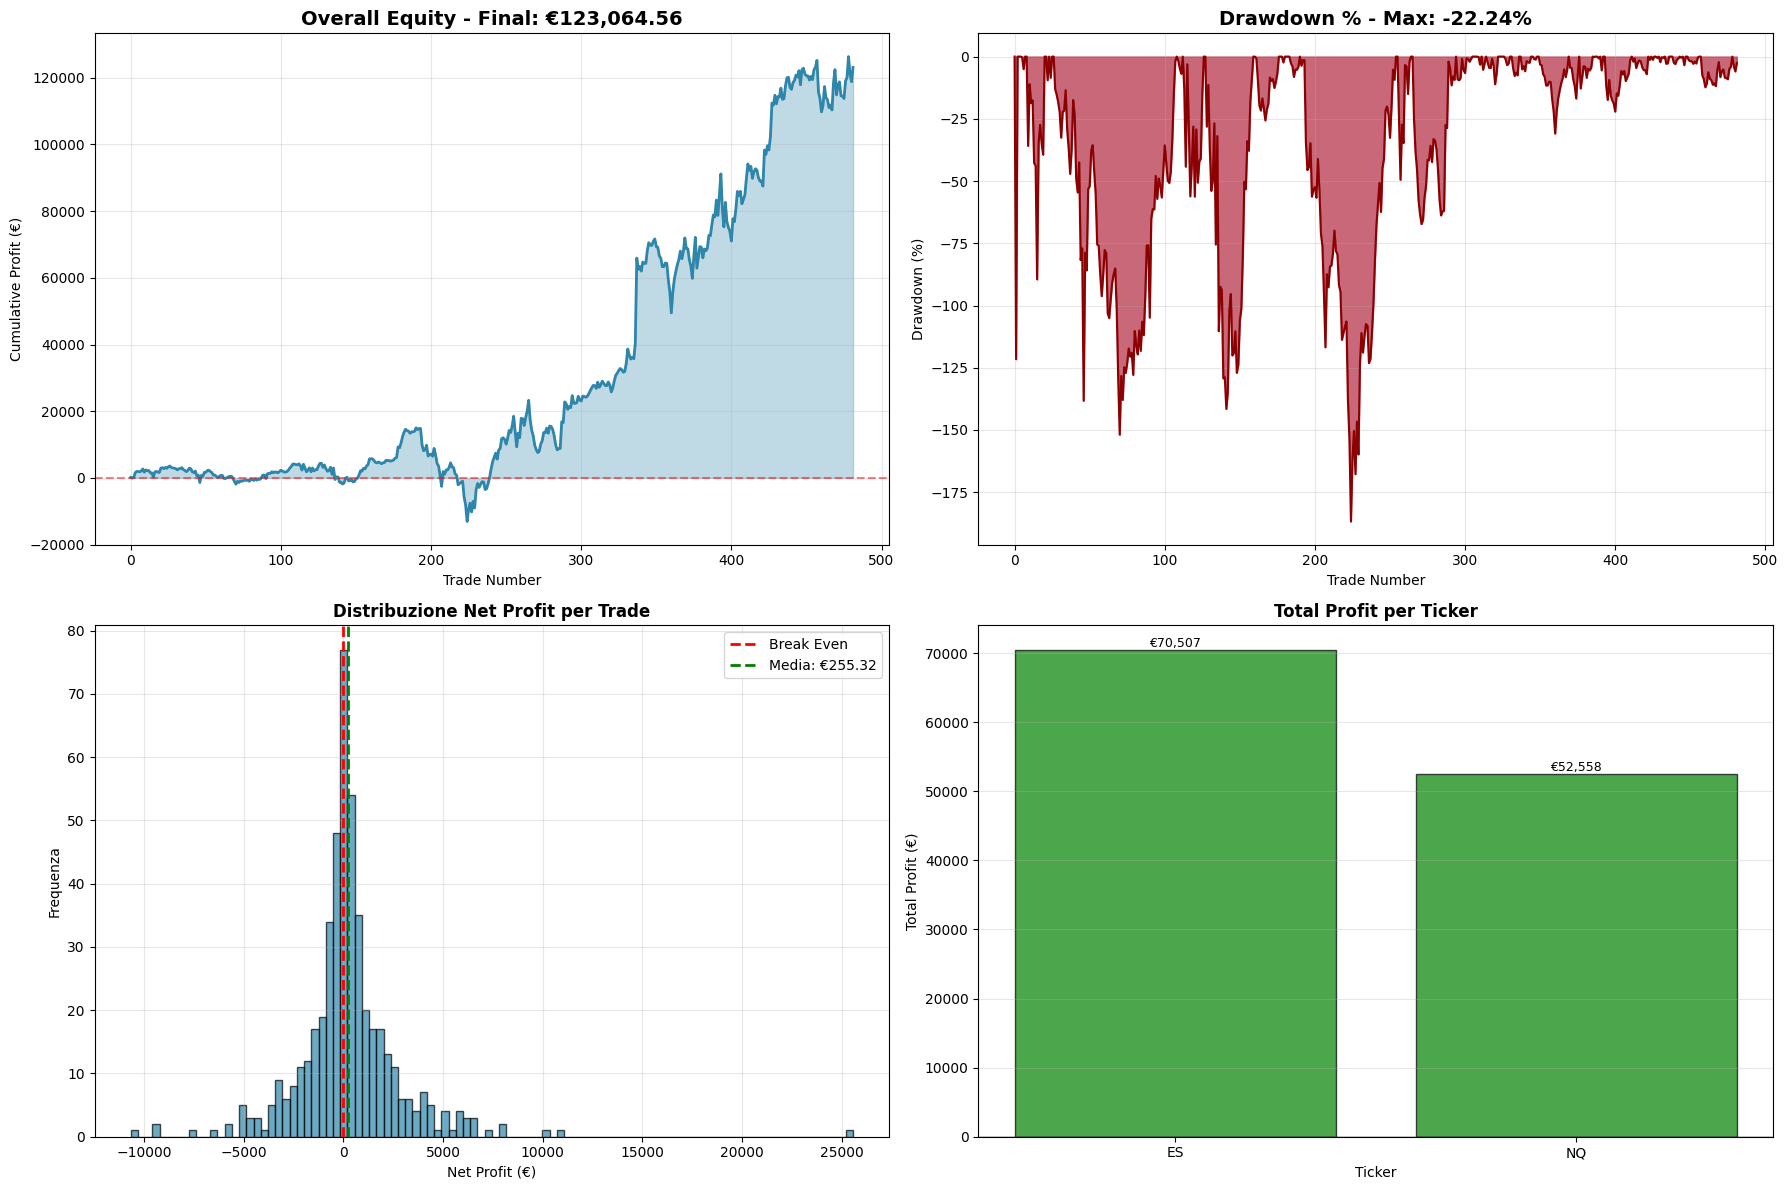

   ✓ Salvato: overall_performance.png


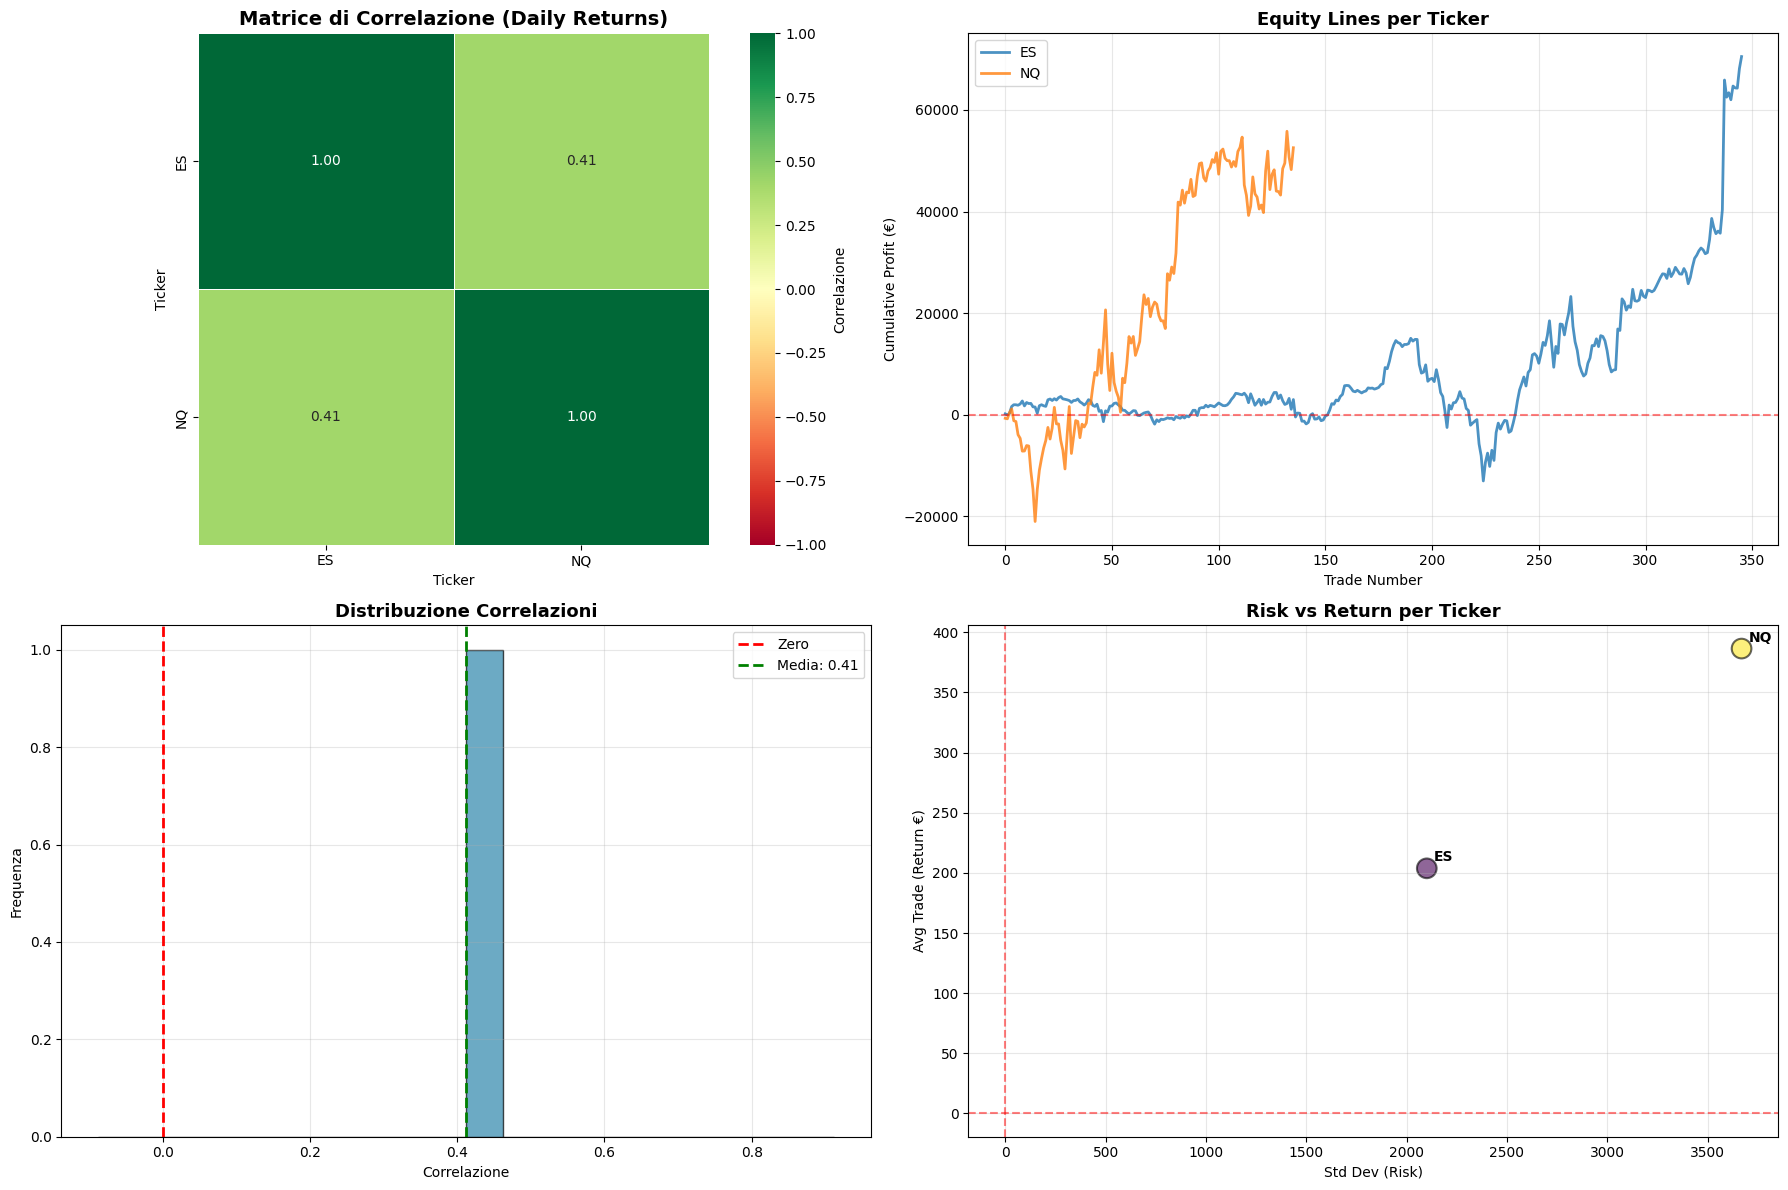

   ✓ Salvato: correlation_analysis.png

💾 Esportazione risultati...

✅ File salvati:
   - overall_metrics.csv
   - overall_performance.png
   - correlation_matrix.csv
   - performance_per_ticker.csv
   - all_trades.csv
   - correlation_analysis.png
   - correlation_pairs.csv

🎉 ANALISI COMPLETA!


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform

# ========================================
# 0. CARICAMENTO CSV
# ========================================

path = r'C:\Users\roman\Desktop\quant\pattern 5 csv\*.csv'
all_files = glob.glob(path)

print(f"📁 Trovati {len(all_files)} file CSV\n")

def estrai_ticker_da_filename(filepath):
    filename = os.path.basename(filepath).replace('.csv', '')
    # Rimuovi suffissi come "_m15", " m15", etc.
    if '_' in filename:
        ticker = filename.split('_')[0].upper()
    elif ' ' in filename:
        ticker = filename.split()[0].upper()
    else:
        ticker = filename.upper()
    return ticker

def pulisci_profit(series):
    """
    Pulisce colonna Profit con formato:
    - Negativi: ($23.78) -> -23.78
    - Positivi: $176.22 -> 176.22
    """
    def clean_value(val):
        if pd.isna(val):
            return np.nan
        
        val_str = str(val).strip()
        
        # Rimuovi $
        val_str = val_str.replace('$', '')
        
        # Gestisci parentesi (negativi)
        if '(' in val_str and ')' in val_str:
            val_str = val_str.replace('(', '').replace(')', '')
            val_str = '-' + val_str
        
        # Rimuovi spazi
        val_str = val_str.replace(' ', '')
        
        try:
            return float(val_str)
        except:
            return np.nan
    
    return series.apply(clean_value)

# Carica tutti i CSV
dfs = []
ticker_count = {}

for file in all_files:
    try:
        # Leggi il CSV con virgola come separatore
        temp_df = pd.read_csv(file, sep=',')
        
        ticker = estrai_ticker_da_filename(file)
        temp_df['Ticker'] = ticker
        ticker_count[ticker] = ticker_count.get(ticker, 0) + 1
        dfs.append(temp_df)
        
        print(f"   ✓ {os.path.basename(file)[:40]:.<40} -> {ticker:.<8} ({len(temp_df):,} righe)")
        
    except Exception as e:
        print(f"   ✗ Errore: {os.path.basename(file)}: {e}")

if not dfs:
    print("\n❌ ERRORE: Nessun file caricato!")
    exit()

df = pd.concat(dfs, ignore_index=True)

print(f"\n📊 Dataset totale: {len(df):,} righe")
print(f"🎯 Ticker: {list(ticker_count.keys())}")

# ========================================
# 1. PULISCI DATI
# ========================================

print("\n🔍 Pulizia dati...")

# Verifica che esista la colonna Profit
if 'Profit' not in df.columns:
    print(f"\n❌ Colonna 'Profit' non trovata!")
    print(f"Colonne disponibili: {list(df.columns)}")
    exit()

# Mostra sample PRIMA della pulizia
print(f"\n📋 Sample 'Profit' PRIMA pulizia:")
print(df['Profit'].head(10).tolist())

# Pulisci la colonna Profit
df['Net profit'] = pulisci_profit(df['Profit'])

# Mostra sample DOPO la pulizia
print(f"\n🧹 Sample 'Net profit' DOPO pulizia:")
print(df['Net profit'].head(10).tolist())

# Pulisci le date
if 'Entry time' in df.columns:
    df['Period'] = pd.to_datetime(df['Entry time'], format='%m/%d/%Y %I:%M:%S %p', errors='coerce')
    df['Date'] = df['Period'].dt.date
    print(f"\n✅ Date parsate correttamente")
elif 'Exit time' in df.columns:
    df['Period'] = pd.to_datetime(df['Exit time'], format='%m/%d/%Y %I:%M:%S %p', errors='coerce')
    df['Date'] = df['Period'].dt.date
    print(f"\n✅ Date parsate da Exit time")
else:
    df['Date'] = pd.date_range(start='2020-01-01', periods=len(df), freq='D').date
    print(f"\n⚠️ Nessuna colonna date, uso indice sequenziale")

# Rimuovi NaN
before = len(df)
df = df.dropna(subset=['Net profit'])
df = df[df['Ticker'].notna()]
print(f"\n🧹 Righe valide: {len(df):,} (rimosse {before - len(df):,})")

# Statistiche base
print(f"\n📊 Statistiche base NET PROFIT:")
print(f"   Min:   €{df['Net profit'].min():,.2f}")
print(f"   Max:   €{df['Net profit'].max():,.2f}")
print(f"   Mean:  €{df['Net profit'].mean():.2f}")
print(f"   Total: €{df['Net profit'].sum():,.2f}")

# ========================================
# 2. VERIFICA PER TICKER
# ========================================

print("\n" + "="*70)
print("🎯 STATISTICHE PER TICKER")
print("="*70)

tickers_unici = sorted(df['Ticker'].unique())

for ticker in tickers_unici:
    df_ticker = df[df['Ticker'] == ticker]
    total_profit = df_ticker['Net profit'].sum()
    
    print(f"\n{ticker}:")
    print(f"  Trade totali:  {len(df_ticker):,}")
    print(f"  Total Profit:  €{total_profit:,.2f}")
    print(f"  Avg Trade:     €{df_ticker['Net profit'].mean():.2f}")
    print(f"  Win Rate:      {(df_ticker['Net profit'] > 0).sum() / len(df_ticker) * 100:.1f}%")
    print(f"  Best Trade:    €{df_ticker['Net profit'].max():.2f}")
    print(f"  Worst Trade:   €{df_ticker['Net profit'].min():.2f}")

# ========================================
# 3. ANALISI OVERALL
# ========================================

print("\n" + "="*70)
print("📈 OVERALL PERFORMANCE (TUTTI I TICKER)")
print("="*70)

def calcola_metriche(returns):
    """Calcola metriche complete per un array di returns"""
    equity = np.cumsum(returns)
    
    # Maximum Drawdown
    running_max = np.maximum.accumulate(equity)
    running_max = np.where(running_max == 0, 1, running_max)
    drawdown = equity - running_max
    max_dd = np.min(drawdown)
    max_dd_pct = (max_dd / np.max(running_max) * 100) if np.max(running_max) > 0 else 0
    
    # Sharpe Ratio (annualizzato)
    if len(returns) > 1 and np.std(returns) > 0:
        sharpe = np.mean(returns) / np.std(returns) * np.sqrt(252)
    else:
        sharpe = 0
    
    # Win rate e profit factor
    wins = returns[returns > 0]
    losses = returns[returns < 0]
    
    total_wins = np.sum(wins)
    total_losses = np.abs(np.sum(losses))
    pf = total_wins / total_losses if total_losses > 0 else np.inf
    
    return {
        'Total Trades': len(returns),
        'Total Profit': equity[-1],
        'Avg Trade': np.mean(returns),
        'Win Rate %': len(wins) / len(returns) * 100,
        'Profit Factor': pf,
        'Sharpe Ratio': sharpe,
        'Max DD €': max_dd,
        'Max DD %': max_dd_pct,
        'Best Trade': np.max(returns),
        'Worst Trade': np.min(returns),
        'Std Dev': np.std(returns),
        'Equity': equity,
        'Drawdown': drawdown
    }

returns_overall = df['Net profit'].values
metrics_overall = calcola_metriche(returns_overall)
equity_overall = metrics_overall.pop('Equity')
drawdown_overall = metrics_overall.pop('Drawdown')

print("\n📊 METRICHE OVERALL:")
for key, value in metrics_overall.items():
    if 'Ratio' in key or '%' in key:
        print(f"{key:.<30} {value:.2f}")
    elif key == 'Total Trades':
        print(f"{key:.<30} {value:,}")
    else:
        print(f"{key:.<30} €{value:,.2f}")

# ========================================
# 4. CORRELAZIONE (DAILY RETURNS)
# ========================================

print("\n" + "="*70)
print("🔗 ANALISI CORRELAZIONE")
print("="*70)

# Aggrega per data e ticker (somma i trade dello stesso giorno)
daily_returns = df.groupby(['Date', 'Ticker'])['Net profit'].sum().unstack(fill_value=0)

print(f"\n📅 Daily returns:")
print(f"   Shape: {daily_returns.shape}")
print(f"   Date range: {daily_returns.index[0]} to {daily_returns.index[-1]}")
print(f"   Giorni totali: {len(daily_returns)}")

# Calcola correlazione
correlation_matrix = daily_returns.corr(method='pearson')

print("\n📊 MATRICE DI CORRELAZIONE (daily returns):")
print(correlation_matrix.round(3))

if len(tickers_unici) > 1:
    # Statistiche correlazione
    correlazioni_flat = correlation_matrix.values[np.triu_indices_from(correlation_matrix.values, k=1)]
    
    print(f"\n📈 Statistiche Correlazione:")
    print(f"   Media:    {np.mean(correlazioni_flat):>7.3f}")
    print(f"   Mediana:  {np.median(correlazioni_flat):>7.3f}")
    print(f"   Min:      {np.min(correlazioni_flat):>7.3f}")
    print(f"   Max:      {np.max(correlazioni_flat):>7.3f}")
    
    # Top coppie correlate
    corr_pairs = []
    for i in range(len(correlation_matrix.columns)):
        for j in range(i+1, len(correlation_matrix.columns)):
            corr_pairs.append({
                'Ticker_1': correlation_matrix.columns[i],
                'Ticker_2': correlation_matrix.columns[j],
                'Correlation': correlation_matrix.iloc[i, j]
            })
    
    corr_pairs_df = pd.DataFrame(corr_pairs).sort_values('Correlation', ascending=False)
    
    print("\n🔥 TOP 5 COPPIE PIÙ CORRELATE:")
    print(corr_pairs_df.head().to_string(index=False))
    
    print("\n❄️ TOP 5 COPPIE MENO CORRELATE:")
    print(corr_pairs_df.tail().to_string(index=False))

# ========================================
# 5. METRICHE DETTAGLIATE PER TICKER
# ========================================

print("\n" + "="*70)
print("🎯 PERFORMANCE DETTAGLIATA PER TICKER")
print("="*70)

perf_list = []
for ticker in tickers_unici:
    ticker_returns = df[df['Ticker'] == ticker]['Net profit'].values
    
    if len(ticker_returns) > 0:
        metrics = calcola_metriche(ticker_returns)
        metrics.pop('Equity')
        metrics.pop('Drawdown')
        metrics['Ticker'] = ticker
        
        if len(tickers_unici) > 1:
            metrics['Avg Corr'] = correlation_matrix[ticker].drop(ticker).mean()
        else:
            metrics['Avg Corr'] = 0
        
        perf_list.append(metrics)

perf_df = pd.DataFrame(perf_list)
perf_df = perf_df[['Ticker', 'Total Trades', 'Total Profit', 'Avg Trade', 
                    'Win Rate %', 'Profit Factor', 'Sharpe Ratio', 
                    'Max DD %', 'Std Dev', 'Avg Corr']]
perf_df = perf_df.sort_values('Total Profit', ascending=False)

print("\n" + perf_df.to_string(index=False))

# ========================================
# 6. METRICHE DI DIVERSIFICAZIONE
# ========================================

if len(tickers_unici) > 1:
    print("\n" + "="*70)
    print("🎯 METRICHE DI DIVERSIFICAZIONE")
    print("="*70)
    
    vol_individuali = daily_returns.std()
    vol_portafoglio = daily_returns.mean(axis=1).std()
    
    if vol_portafoglio > 0:
        diversification_ratio = vol_individuali.mean() / vol_portafoglio
        print(f"\nDiversification Ratio: {diversification_ratio:.2f}")
        if diversification_ratio > 2:
            print("  ✅ Ottimo (>2) - Buona diversificazione")
        elif diversification_ratio > 1:
            print("  ⚠️ Buono (1-2) - Diversificazione moderata")
        else:
            print("  ❌ Scarso (<1) - Diversificazione limitata")
    
    avg_pairwise_corr = np.mean(correlazioni_flat)
    print(f"\nCorrelazione Media tra Coppie: {avg_pairwise_corr:.3f}")
    if abs(avg_pairwise_corr) < 0.3:
        print("  ✅ Bassa (<0.3) - Ottimo per diversificazione")
    elif abs(avg_pairwise_corr) < 0.7:
        print("  ⚠️ Moderata (0.3-0.7)")
    else:
        print("  ❌ Alta (>0.7) - Limitata diversificazione")
    
    negative_corr_count = (correlazioni_flat < 0).sum()
    total_pairs = len(correlazioni_flat)
    print(f"\nCoppie con Correlazione Negativa: {negative_corr_count}/{total_pairs} ({negative_corr_count/total_pairs*100:.1f}%)")
    print("  (Più alto = migliore hedging naturale)")

# ========================================
# 7. GRAFICI
# ========================================

print("\n📊 Generazione grafici...")

# --- FIGURA 1: Overall Performance ---
fig1, axes = plt.subplots(2, 2, figsize=(18, 12))

# Equity curve
ax1 = axes[0, 0]
ax1.plot(equity_overall, linewidth=2, color='#2E86AB')
ax1.fill_between(range(len(equity_overall)), 0, equity_overall, alpha=0.3, color='#2E86AB')
ax1.axhline(y=0, color='red', linestyle='--', alpha=0.5)
ax1.set_title(f'Overall Equity - Final: €{equity_overall[-1]:,.2f}', 
              fontsize=14, fontweight='bold')
ax1.set_xlabel('Trade Number')
ax1.set_ylabel('Cumulative Profit (€)')
ax1.grid(True, alpha=0.3)
ax1.ticklabel_format(style='plain', axis='y')

# Drawdown
ax2 = axes[0, 1]
running_max_overall = np.maximum.accumulate(equity_overall)
running_max_overall = np.where(running_max_overall == 0, 1, running_max_overall)
drawdown_pct = (drawdown_overall / running_max_overall * 100)
ax2.fill_between(range(len(drawdown_pct)), 0, drawdown_pct, color='#A4031F', alpha=0.6)
ax2.plot(drawdown_pct, linewidth=1.5, color='#8B0000')
ax2.set_title(f'Drawdown % - Max: {metrics_overall["Max DD %"]:.2f}%', 
              fontsize=14, fontweight='bold')
ax2.set_xlabel('Trade Number')
ax2.set_ylabel('Drawdown (%)')
ax2.grid(True, alpha=0.3)

# Distribuzione
ax3 = axes[1, 0]
ax3.hist(df['Net profit'], bins=100, color='#2E86AB', alpha=0.7, edgecolor='black')
ax3.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Break Even')
ax3.axvline(x=df['Net profit'].mean(), color='green', linestyle='--', 
            linewidth=2, label=f'Media: €{df["Net profit"].mean():.2f}')
ax3.set_title('Distribuzione Net Profit per Trade', fontsize=12, fontweight='bold')
ax3.set_xlabel('Net Profit (€)')
ax3.set_ylabel('Frequenza')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Profit per ticker
ax4 = axes[1, 1]
ticker_profits = [df[df['Ticker'] == t]['Net profit'].sum() for t in tickers_unici]
colors = ['green' if p > 0 else 'red' for p in ticker_profits]
bars = ax4.bar(tickers_unici, ticker_profits, color=colors, alpha=0.7, edgecolor='black')
ax4.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax4.set_title('Total Profit per Ticker', fontsize=12, fontweight='bold')
ax4.set_xlabel('Ticker')
ax4.set_ylabel('Total Profit (€)')
ax4.grid(True, alpha=0.3, axis='y')
ax4.ticklabel_format(style='plain', axis='y')

# Valori sulle barre
for bar, profit in zip(bars, ticker_profits):
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height,
            f'€{profit:,.0f}',
            ha='center', va='bottom' if height > 0 else 'top', fontsize=9)

plt.tight_layout()
plt.savefig('overall_performance.png', dpi=300, bbox_inches='tight')
plt.show()

print("   ✓ Salvato: overall_performance.png")

# --- FIGURA 2: Correlazione ---
if len(tickers_unici) > 1:
    fig2, axes = plt.subplots(2, 2, figsize=(18, 12))
    
    # Heatmap
    ax1 = axes[0, 0]
    sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
                center=0, vmin=-1, vmax=1, square=True, linewidths=0.5,
                cbar_kws={'label': 'Correlazione'}, ax=ax1, annot_kws={'size': 10})
    ax1.set_title('Matrice di Correlazione (Daily Returns)', 
                  fontsize=14, fontweight='bold')
    
    # Equity per ticker
    ax2 = axes[0, 1]
    for ticker in tickers_unici:
        ticker_equity = df[df['Ticker'] == ticker]['Net profit'].cumsum()
        ax2.plot(ticker_equity.values, label=ticker, linewidth=2, alpha=0.8)
    ax2.set_title('Equity Lines per Ticker', fontsize=13, fontweight='bold')
    ax2.set_xlabel('Trade Number')
    ax2.set_ylabel('Cumulative Profit (€)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.axhline(y=0, color='red', linestyle='--', alpha=0.5)
    ax2.ticklabel_format(style='plain', axis='y')
    
    # Distribuzione correlazioni
    ax3 = axes[1, 0]
    ax3.hist(correlazioni_flat, bins=20, color='#2E86AB', alpha=0.7, edgecolor='black')
    ax3.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero')
    ax3.axvline(x=np.mean(correlazioni_flat), color='green', linestyle='--', 
                linewidth=2, label=f'Media: {np.mean(correlazioni_flat):.2f}')
    ax3.set_title('Distribuzione Correlazioni', fontsize=13, fontweight='bold')
    ax3.set_xlabel('Correlazione')
    ax3.set_ylabel('Frequenza')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # Risk-Return scatter
    ax4 = axes[1, 1]
    avg_returns = [perf_df[perf_df['Ticker'] == t]['Avg Trade'].values[0] for t in tickers_unici]
    std_devs = [perf_df[perf_df['Ticker'] == t]['Std Dev'].values[0] for t in tickers_unici]
    
    scatter = ax4.scatter(std_devs, avg_returns, s=200, alpha=0.6, 
                         c=range(len(tickers_unici)), cmap='viridis',
                         edgecolors='black', linewidth=1.5)
    for i, ticker in enumerate(tickers_unici):
        ax4.annotate(ticker, (std_devs[i], avg_returns[i]),
                    xytext=(5, 5), textcoords='offset points', 
                    fontsize=10, fontweight='bold')
    ax4.axhline(y=0, color='red', linestyle='--', alpha=0.5)
    ax4.axvline(x=0, color='red', linestyle='--', alpha=0.5)
    ax4.set_title('Risk vs Return per Ticker', fontsize=13, fontweight='bold')
    ax4.set_xlabel('Std Dev (Risk)')
    ax4.set_ylabel('Avg Trade (Return €)')
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('correlation_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("   ✓ Salvato: correlation_analysis.png")

# ========================================
# 8. EXPORT RISULTATI
# ========================================

print("\n💾 Esportazione risultati...")

# Metriche overall
overall_export = pd.DataFrame([metrics_overall])
overall_export.to_csv('overall_metrics.csv', index=False)

# Correlazione
correlation_matrix.to_csv('correlation_matrix.csv')

# Performance per ticker
perf_df.to_csv('performance_per_ticker.csv', index=False)

# Coppie correlazione
if len(tickers_unici) > 1:
    corr_pairs_df.to_csv('correlation_pairs.csv', index=False)

# Trade completi
df[['Ticker', 'Period', 'Net profit']].to_csv('all_trades.csv', index=False)

print("\n✅ File salvati:")
print("   - overall_metrics.csv")
print("   - overall_performance.png")
print("   - correlation_matrix.csv")
print("   - performance_per_ticker.csv")
print("   - all_trades.csv")
if len(tickers_unici) > 1:
    print("   - correlation_analysis.png")
    print("   - correlation_pairs.csv")

print("\n" + "="*70)
print("🎉 ANALISI COMPLETA!")
print("="*70)